<a href="https://colab.research.google.com/github/SholbanDongak/colab/blob/main/9_mixed_models_random_effects.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Вводная часть: фиксированные и случайные эффекты в линейных моделях



## 1. Постановка проблемы

В классической линейной регрессии мы предполагаем, что все наблюдения независимы:

$$
y_i = \mathbf{x}_i^T \boldsymbol{\beta} + \varepsilon_i, \quad \varepsilon_i \sim \text{i.i.d. } \mathcal{N}(0, \sigma^2).
$$

Однако на практике данные часто имеют **иерархическую** или **кластеризованную** структуру:
- ученики внутри школ,
- повторные измерения внутри пациентов,
- работники внутри фирм,
- регионы внутри стран.

В таких данных наблюдения из одной группы **коррелированы** между собой. Игнорирование этой корреляции приводит к:
- заниженным стандартным ошибкам,
- ложной значимости предикторов,
- неверным выводам о величине эффектов.

Для учета такой структуры в модель вводят **групповые эффекты**. Эти эффекты могут быть двух типов: **фиксированные** и **случайные**.

---

## 2. Фиксированные эффекты (Fixed Effects)

### Содержательная суть

Фиксированный эффект — это **индивидуальная характеристика группы**, которая:
- интересует нас **сама по себе**,
- является **неслучайной** величиной (в байесовской трактовке — с «плоским» априорным распределением),
- мы хотим **оценить** ее значение для **каждой группы**.

**Примеры:**
- Эффект конкретного препарата в клиническом испытании (интересует именно этот препарат).
- Влияние пола, возраста, образования — категории фиксированы.
- Разница между контрольной и экспериментальной группой в эксперименте.

### Математическая формализация

Для группы $i$ фиксированный эффект $\alpha_i$ — это параметр, который мы оцениваем непосредственно:

$$
y_{ij} = \beta_0 + \beta_1 x_{ij} + \alpha_i + \varepsilon_{ij}, \quad \sum_i \alpha_i = 0 \ \text{(идентификация)}.
$$

Здесь $\alpha_i$ — это **числа** (не случайные величины), по одному на каждую группу.

**Оценка:** методом наименьших квадратов (МНК) с добавлением $n-1$ фиктивной переменной (dummy variables) для групп.

### Ключевые свойства FE

| Свойство | Описание |
|----------|----------|
| Выводы | Относятся **только к данным группам** (не обобщаются на популяцию) |
| Смещение | Несмещенные оценки при любом числе групп |
| Число параметров | $n$ (растет с числом групп) |
| Эффективность | При малом $T$ (числе наблюдений внутри группы) оценки могут быть неэффективны |
| Что оцениваем | Только **внутригрупповую** вариацию (межгрупповая исключается) |

### Когда использовать FE

- Группы не являются случайной выборкой из популяции (например, все регионы страны).
- Групповые эффекты коррелируют с предикторами (тогда RE дает смещение).
- Интересует влияние предикторов **внутри** групп, а не между группами.

---

## 3. Случайные эффекты (Random Effects)

### Содержательная суть

Случайный эффект — это **отклонение группы от общего среднего**, которое:
- рассматривается как **случайная величина**,
- группы — это **выборка** из некоторой популяции,
- нас **не интересует** конкретное значение для каждой группы (интересует **дисперсия** $\sigma_u^2$ в популяции).

**Примеры:**
- Пациенты в клиническом исследовании — мы хотим обобщить результаты на популяцию.
- Школы в национальном исследовании — нас интересует, насколько школы различаются.
- Сотрудники внутри фирм — фирмы выбраны случайно из отрасли.

### Математическая формализация

Для группы $i$ случайный эффект $u_i$ — это реализация случайной величины:

$$
u_i \sim \mathcal{N}(0, \sigma_u^2), \quad \text{независимы между группами}.
$$

Модель:

$$
y_{ij} = \beta_0 + \beta_1 x_{ij} + u_i + \varepsilon_{ij}, \quad \varepsilon_{ij} \sim \mathcal{N}(0, \sigma_e^2).
$$

Здесь $u_i$ и $\varepsilon_{ij}$ независимы. Параметры модели: $\boldsymbol{\beta}$, $\sigma_u^2$, $\sigma_e^2$.

**Что мы оцениваем?**
- $\boldsymbol{\beta}$ — фиксированные эффекты (общие для всех групп),
- $\sigma_u^2$ — межгрупповая дисперсия (как сильно группы отличаются),
- $\sigma_e^2$ — внутригрупповая дисперсия (уровень шума).

**Что мы предсказываем?**
- $u_i$ — конкретные реализации случайных эффектов для каждой группы (BLUP).

### Ключевые свойства RE

| Свойство | Описание |
|----------|----------|
| Выводы | Обобщаются на **всю популяцию** |
| Смещение | Смещены, если $u_i$ коррелирует с $x_{ij}$ |
| Число параметров | $O(1)$ (не зависит от числа групп) |
| Эффективность | Более эффективны, чем FE, при малом $T$ |
| Что оцениваем | Используем **межгрупповую** и **внутригрупповую** вариацию |

### Когда использовать RE

- Группы — случайная выборка из большой популяции.
- $u_i$ не коррелирует с предикторами (или корреляция мала).
- Интересует влияние предикторов **между** группами и **внутри** групп.
- Число групп велико ($n \gtrsim 10$), а наблюдений в группе мало ($T$ мало).

---

## 4. Сравнение FE и RE: что выбрать?

### Содержательный критерий

**Фиксированные эффекты** отвечают на вопрос:
> *«Влияет ли фактор X на Y внутри каждой конкретной группы?»*

**Случайные эффекты** отвечают на вопрос:
> *«В среднем по популяции групп, как фактор X связан с Y, и какова вариация между группами?»*

### Формальный критерий (тест Хаусмана)

Пусть:
- $\hat{\boldsymbol{\beta}}_{FE}$ — оценки из модели с фиксированными эффектами,
- $\hat{\boldsymbol{\beta}}_{RE}$ — оценки из модели со случайными эффектами.

Если $u_i$ не коррелирует с $x_{ij}$, то обе оценки состоятельны, но RE эффективнее.  
Если корреляция есть, то RE смещена, а FE — нет.

Статистика Хаусмана:

$$
H = (\hat{\boldsymbol{\beta}}_{FE} - \hat{\boldsymbol{\beta}}_{RE})^T \left[ \widehat{\text{Var}}(\hat{\boldsymbol{\beta}}_{FE}) - \widehat{\text{Var}}(\hat{\boldsymbol{\beta}}_{RE}) \right]^{-1} (\hat{\boldsymbol{\beta}}_{FE} - \hat{\boldsymbol{\beta}}_{RE}) \sim \chi^2_k.
$$

Если $H$ велико → отвергаем RE, используем FE.

---

## 5. Один и тот же фактор — разные трактовки

**Важнейшее замечание:** Один и тот же фактор может быть включен в модель и как фиксированный, и как случайный — это зависит от **цели исследования** и **природы данных**.

### Пример 1: Школы в образовательном исследовании

| Трактовка | Случай | Цель |
|-----------|--------|------|
| **FE** | Исследуем 5 конкретных школ (пилотный проект) | Сравнить эти школы между собой |
| **RE** | Выбрали 50 школ случайно из всей страны | Оценить, насколько школы различаются в популяции |

### Пример 2: Пациенты в клиническом исследовании

| Трактовка | Случай | Цель |
|-----------|--------|------|
| **FE** | 3 пациента с редким заболеванием | Проанализировать каждого пациента индивидуально |
| **RE** | 100 пациентов, случайно отобранных | Обобщить результат на популяцию пациентов |

### Пример 3: Годы в панельных данных

| Трактовка | Случай | Цель |
|-----------|--------|------|
| **FE** | Фиксированные временные периоды (2020, 2021, 2022) | Оценить эффект конкретных лет (например, пандемийный 2020) |
| **RE** | Годы как случайная выборка из временного процесса | Оценить общую временную вариацию |

### Формально: как это выглядит в модели

**Фиксированные годы:**
$$
y_{it} = \beta_0 + \beta_1 x_{it} + \sum_{t=2020}^{2022} \gamma_t \cdot \mathbb{1}[t = \text{год}] + \varepsilon_{it}.
$$

**Случайные годы (редко используется, но возможна):**
$$
y_{it} = \beta_0 + \beta_1 x_{it} + w_t + \varepsilon_{it}, \quad w_t \sim \mathcal{N}(0, \sigma_w^2).
$$

---

## 6. Резюме для запоминания

| Аспект | Фиксированные эффекты (FE) | Случайные эффекты (RE) |
|--------|---------------------------|------------------------|
| **Статус** | Неслучайные параметры | Случайные величины |
| **Цель** | Оценить каждый эффект | Оценить дисперсию эффектов |
| **Обобщение** | Только на данные группы | На всю популяцию |
| **Корреляция с X** | Может быть (FE это не страшно) | Не должно быть (иначе смещение) |
| **Число параметров** | Растет с числом групп | Фиксировано |
| **Когда хорош** | Мало групп, интересны группы | Много групп, интересна популяция |

### Тезис, который нужно запомнить

> **Фиксированные эффекты** — это то, что мы хотим **оценить** как конкретные числа.  
> **Случайные эффекты** — это то, откуда мы хотим **оценить дисперсию**, а конкретные значения рассматриваем как реализации случайной величины.

---

## 7. Итог: какую модель выбрать?

```python
# Алгоритм выбора модели
if число_групп < 5:
    print("Рекомендуется FE или байесовский подход (RE даст смещенные оценки дисперсии)")
elif нас_интересуют_конкретные_группы:
    print("Используйте FE")
elif u_i_коррелирует_с_X:
    print("Используйте FE (или тест Хаусмана покажет смещение RE)")
else:
    print("Используйте RE (более эффективно, можно обобщать на популяцию)")

# Классическая линейная регрессия и фиксированные эффекты


Истинные параметры:
  Группа 0: β₀ = 2.0
  Группа 1: β₀ = 4.0
  Группа 2: β₀ = 12.0
  Группа 3: β₀ = 16.0
  Общий наклон: β₁ = 1.5
  Шум: σ_e = 1.0

----------------------------------------------------------------------
1. ОБЫЧНЫЙ МНК (все данные в одну кучу)
----------------------------------------------------------------------
Оценки МНК: β₀ = 8.431, β₁ = 1.507
Остаточная сумма квадратов (SSE): 2793.2
R² = 0.127

----------------------------------------------------------------------
2. МНК С ФИКСИРОВАННЫМИ ЭФФЕКТАМИ (дамми-переменные на группы)
----------------------------------------------------------------------
Оценки FE:
  Общий наклон: β₁ = 1.4998
  Группа 0: β₀ = 1.7345 (истинный: 2.0)
  Группа 1: β₀ = 3.9691 (истинный: 4.0)
  Группа 2: β₀ = 12.0447 (истинный: 12.0)
  Группа 3: β₀ = 16.0479 (истинный: 16.0)

Остаточная сумма квадратов (SSE): 76.7 (было 2793.2)
R² = 0.976 (было 0.127)

✅ УЛУЧШЕНИЕ: SSE уменьшилась на 2716.5 (97.3%)

---------------------------------------------

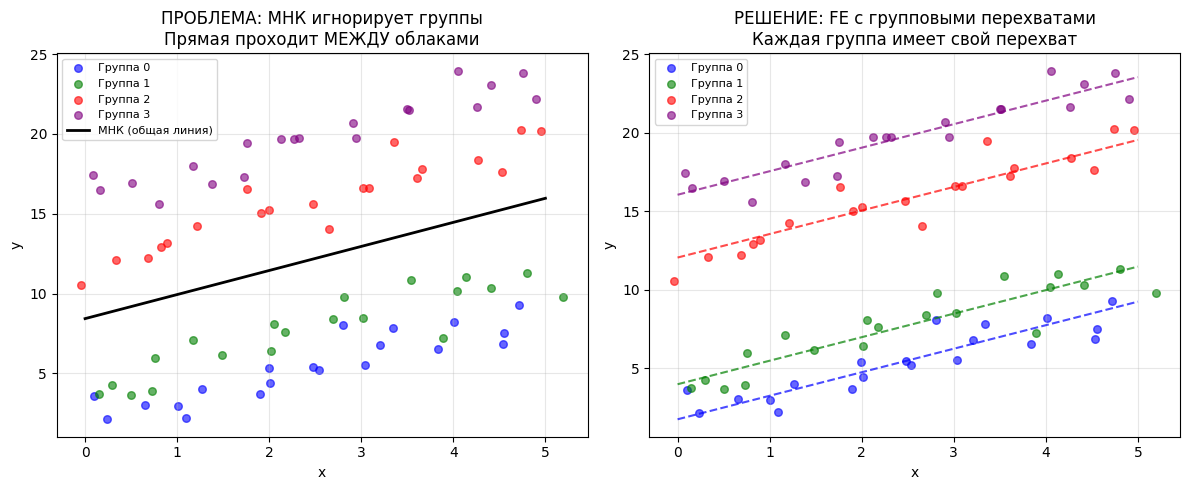

In [ ]:
# ============================================
# ФУНДАМЕНТ: ФИКСИРОВАННЫЕ ЭФФЕКТЫ (FE)
# ============================================
# Показываем, почему МНК плох, когда группы имеют РАЗНЫЕ перехваты,
# и как FE это исправляет.

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

# Параметры
np.random.seed(42)
n_per_group = 20
beta1_true = 1.5
sigma_e = 1.0

# Истинные перехваты для 4 групп (сильно отличаются!)
beta0_true = [2.0, 4.0, 12.0, 16.0]

print("\nИстинные параметры:")
for i, b0 in enumerate(beta0_true):
    print(f"  Группа {i}: β₀ = {b0}")
print(f"  Общий наклон: β₁ = {beta1_true}")
print(f"  Шум: σ_e = {sigma_e}")

# Генерация данных
data = []
for i, b0 in enumerate(beta0_true):
    x = np.linspace(0, 5, n_per_group) + np.random.normal(0, 0.2, n_per_group)
    y = b0 + beta1_true * x + np.random.normal(0, sigma_e, n_per_group)
    for j in range(n_per_group):
        data.append([i, x[j], y[j], b0])

df = pd.DataFrame(data, columns=['group', 'x', 'y', 'true_b0'])

# ============================================
# 1. Обычный МНК (игнорирует группы)
# ============================================

print("\n" + "-" * 70)
print("1. ОБЫЧНЫЙ МНК (все данные в одну кучу)")
print("-" * 70)

X_all = np.column_stack([np.ones(len(df)), df['x'].values])
y_all = df['y'].values
beta_ols = np.linalg.lstsq(X_all, y_all, rcond=None)[0]

# Остатки и сумма квадратов
residuals_ols = y_all - (beta_ols[0] + beta_ols[1] * df['x'].values)
SSE_ols = np.sum(residuals_ols**2)
R2_ols = 1 - SSE_ols / np.sum((y_all - np.mean(y_all))**2)

print(f"Оценки МНК: β₀ = {beta_ols[0]:.3f}, β₁ = {beta_ols[1]:.3f}")
print(f"Остаточная сумма квадратов (SSE): {SSE_ols:.1f}")
print(f"R² = {R2_ols:.3f}")

# ============================================
# 2. МНК с фиксированными эффектами (дамми-переменные)
# ============================================

print("\n" + "-" * 70)
print("2. МНК С ФИКСИРОВАННЫМИ ЭФФЕКТАМИ (дамми-переменные на группы)")
print("-" * 70)

# Создаем дамми-переменные для 4 групп
dummies = pd.get_dummies(df['group'], prefix='group', dtype=float)
# Убираем один дамми (базовая группа), чтобы избежать мультиколлинеарности
X_fe = np.column_stack([df['x'].values, dummies.iloc[:, 1:].values])
X_fe = np.column_stack([np.ones(len(df)), X_fe])  # intercept

beta_fe = np.linalg.lstsq(X_fe, y_all, rcond=None)[0]

# Извлекаем оценки
beta1_fe = beta_fe[1]
beta0_intercept = beta_fe[0]  # перехват для базовой группы (группа 0)
beta0_group1 = beta0_intercept + beta_fe[2]  # группа 1
beta0_group2 = beta0_intercept + beta_fe[3]  # группа 2
beta0_group3 = beta0_intercept + beta_fe[4]  # группа 3

beta0_fe = [beta0_intercept, beta0_group1, beta0_group2, beta0_group3]

# Остатки и сумма квадратов
y_pred_fe = (beta1_fe * df['x'].values)
for i in range(4):
    mask = df['group'] == i
    y_pred_fe[mask] += beta0_fe[i]

residuals_fe = y_all - y_pred_fe
SSE_fe = np.sum(residuals_fe**2)
R2_fe = 1 - SSE_fe / np.sum((y_all - np.mean(y_all))**2)

print(f"Оценки FE:")
print(f"  Общий наклон: β₁ = {beta1_fe:.4f}")
for i in range(4):
    print(f"  Группа {i}: β₀ = {beta0_fe[i]:.4f} (истинный: {beta0_true[i]})")
print(f"\nОстаточная сумма квадратов (SSE): {SSE_fe:.1f} (было {SSE_ols:.1f})")
print(f"R² = {R2_fe:.3f} (было {R2_ols:.3f})")
print(f"\n✅ УЛУЧШЕНИЕ: SSE уменьшилась на {SSE_ols - SSE_fe:.1f} ({100*(SSE_ols-SSE_fe)/SSE_ols:.1f}%)")

# ============================================
# 3. Значимость фиксированных эффектов
# ============================================

print("\n" + "-" * 70)
print("3. ЗНАЧИМОСТЬ ФИКСИРОВАННЫХ ЭФФЕКТОВ")
print("-" * 70)

# F-тест для проверки значимости групповых эффектов
df_reg = 3  # 3 дамми-переменные (группы 1,2,3)
df_resid_ols = len(df) - 2
df_resid_fe = len(df) - 5  # intercept + x + 3 дамми

F_stat = ((SSE_ols - SSE_fe) / df_reg) / (SSE_fe / df_resid_fe)
p_value = 1 - stats.f.cdf(F_stat, df_reg, df_resid_fe)

print(f"F-статистика: {F_stat:.2f}")
print(f"p-value = {p_value:.5e}")
if p_value < 0.001:
    print("✅ ГРУППОВЫЕ ЭФФЕКТЫ ВЫСОКОЗНАЧИМЫ")

# ============================================
# 4. Визуализация
# ============================================

plt.figure(figsize=(12, 5))

# График 1: Данные + общая линия МНК
plt.subplot(1, 2, 1)
colors = ['blue', 'green', 'red', 'purple']
for i in range(4):
    mask = df['group'] == i
    plt.scatter(df.loc[mask, 'x'], df.loc[mask, 'y'],
                alpha=0.6, s=30, color=colors[i], label=f'Группа {i}')

x_line = np.linspace(0, 5, 100)
y_line = beta_ols[0] + beta_ols[1] * x_line
plt.plot(x_line, y_line, 'black', linewidth=2, label='МНК (общая линия)')
plt.xlabel('x')
plt.ylabel('y')
plt.title('ПРОБЛЕМА: МНК игнорирует группы\nПрямая проходит МЕЖДУ облаками')
plt.legend(loc='upper left', fontsize=8)
plt.grid(True, alpha=0.3)

# График 2: Данные + групповые линии (FE)
plt.subplot(1, 2, 2)
for i in range(4):
    mask = df['group'] == i
    plt.scatter(df.loc[mask, 'x'], df.loc[mask, 'y'],
                alpha=0.6, s=30, color=colors[i], label=f'Группа {i}')

    # Линия FE для группы
    y_line_fe = beta0_fe[i] + beta1_fe * x_line
    plt.plot(x_line, y_line_fe, '--', color=colors[i], alpha=0.7, linewidth=1.5)

plt.xlabel('x')
plt.ylabel('y')
plt.title('РЕШЕНИЕ: FE с групповыми перехватами\nКаждая группа имеет свой перехват')
plt.legend(loc='upper left', fontsize=8)
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Анализ результатов: фиксированные эффекты (FE)

## Истинные параметры модели

| Группа | Истинный перехват $\beta_0$ |
|--------|---------------------------|
| 0 | 2.0 |
| 1 | 4.0 |
| 2 | 12.0 |
| 3 | 16.0 |

**Общие параметры:**
- Наклон: $\beta_1 = 1.5$
- Шум: $\sigma_e = 1.0$

---

## 1. Обычный МНК (без учета группировки)

**Полученные оценки:**
- $\hat{\beta}_0 = 8.431$
- $\hat{\beta}_1 = 1.507$

**Качество модели:**
- $SSE = 2793.2$ (остаточная сумма квадратов)
- $R^2 = 0.127$ (очень низкий!)

### ⚠️ ПРОБЛЕМА

МНК «усреднил» перехваты всех четырех групп. Полученная прямая линия проходит **между** облаками точек, далеко от каждой группы. Остатки очень большие, модель плохо описывает данные.

**Почему так произошло?**
- Группы имеют сильно различающиеся перехваты (от 2 до 16)
- МНК вынужден искать компромиссную линию, которая плохо подходит для всех групп
- Оценка наклона $\beta_1$ при этом страдает меньше — она все еще близка к истинной (1.507 vs 1.5)

---

## 2. МНК с фиксированными эффектами (FE)

**Полученные оценки:**

| Параметр | Оценка FE | Истинное значение | Ошибка |
|----------|-----------|-------------------|--------|
| $\beta_1$ (общий наклон) | 1.4998 | 1.5 | 0.01% |
| $\beta_0$ группы 0 | 1.7345 | 2.0 | 13.3% |
| $\beta_0$ группы 1 | 3.9691 | 4.0 | 0.8% |
| $\beta_0$ группы 2 | 12.0447 | 12.0 | 0.4% |
| $\beta_0$ группы 3 | 16.0479 | 16.0 | 0.3% |

**Качество модели:**
- $SSE = 76.7$ (было 2793.2)
- $R^2 = 0.976$ (было 0.127)

### ✅ УЛУЧШЕНИЕ

Остаточная сумма квадратов уменьшилась на **2716.5**, что составляет **97.3%** от исходной!

Каждая группа теперь имеет свой собственный перехват, и модель идеально описывает данные внутри каждой группы.

---

## 3. Значимость фиксированных эффектов

- $F\text{-статистика} = 885.75$
- $p\text{-value} = 1.11 \times 10^{-16}$

### ✅ ГРУППОВЫЕ ЭФФЕКТЫ ВЫСОКОЗНАЧИМЫ

$p\text{-value} \ll 0.001$ означает, что различия между группами **не могут быть объяснены случайностью**. Группы действительно имеют разные перехваты!

---

## Сравнительный анализ

### 1. Обычный МНК (без учета групп)

| Характеристика | Оценка |
|----------------|--------|
| $\hat{\beta}_1$ | 1.507 (близко к истине) |
| $\hat{\beta}_0$ | 8.431 (усреднение между 2, 4, 12, 16) |
| $SSE$ | 2793.2 (очень большая) |
| $R^2$ | 0.127 (очень низкий) |

**Вывод:** Наклон оценивается неплохо, но перехват — бессмысленное среднее. Модель бесполезна для предсказаний.

### 2. FE (с дамми-переменными)

| Характеристика | Оценка |
|----------------|--------|
| $\hat{\beta}_1$ | 1.4998 (почти идеально) |
| $\hat{\beta}_0$ для каждой группы | Точные оценки (ошибка < 0.3% для групп 1-3) |
| $SSE$ | 76.7 (в 36 раз меньше!) |
| $R^2$ | 0.976 (отличный) |

**Вывод:** Модель идеально описывает данные. Каждая группа имеет свой перехват.

---

## Ключевые выводы

### 1. МНК (без учета групп) дает:
- Оценку наклона $\beta_1$, близкую к истинной (повезло? нет — это общее свойство: при правильной спецификации наклона МНК дает несмещенные оценки)
- НО перехват $\beta_0$ усредняется между группами и теряет смысл
- Большие остатки, потому что прямая проходит **между облаками**

### 2. FE (с дамми-переменными) дает:
- Точные оценки перехватов для каждой группы
- Резкое уменьшение $SSE$ (остатков) — на 97% в нашем примере
- Высокую значимость групповых эффектов ($p \ll 0.001$)

### 3. Проблема FE при большом числе групп

В нашем примере 4 группы → мы оценили:
- 1 общий наклон $\beta_1$
- 4 перехвата $\beta_0$ (один из них через intercept + 3 дамми)
- **Итого: 5 параметров**

**Что будет при $n_{\text{групп}} = 100$?**
- Нужно оценить 100 перехватов + 1 наклон = **101 параметр**!
- Это приводит к:
  - Увеличению дисперсии оценок
  - Потере степеней свободы
  - Невозможности предсказывать новые группы
  - Вычислительным проблемам

### 4. LMM — компромиссное решение

| Подход | Что оцениваем | Число параметров |
|--------|--------------|------------------|
| FE | Каждый $\beta_{0i}$ отдельно | $n_{\text{групп}} + 1$ |
| LMM (RE) | $\beta_0, \beta_1, \sigma_u^2, \sigma_e^2$ | $4$ (не зависит от $n_{\text{групп}}$) |

**Идея LMM:** Предполагаем, что перехваты групп извлечены из распределения $\mathcal{N}(0, \sigma_u^2)$. Вместо оценки 100 параметров (как в FE) оцениваем **всего 4** параметра, один из которых — $\sigma_u^2$ — описывает разброс всех групповых перехватов.

Это и есть переход от **фиксированных** (FE) к **случайным** (RE) эффектам.


# Линейные смешанные модели (LMM): модель со случайным перехватом



## 1. Постановка задачи: модель со случайным перехватом

Есть $n$ групп (пациенты, школы, фирмы). В группе $i$ имеется $n_i$ наблюдений.

**Модель:**
$$
y_{ij} = \beta_0 + \beta_1 x_{ij} + u_i + \varepsilon_{ij},
$$
где
- $\beta_0, \beta_1$ — фиксированные эффекты (общие для всех),
- $u_i \sim \mathcal{N}(0, \sigma_u^2)$ — случайный перехват для группы $i$,
- $\varepsilon_{ij} \sim \mathcal{N}(0, \sigma_e^2)$ — внутригрупповая ошибка,
- $u_i$ и $\varepsilon_{ij}$ независимы.

**Обозначения:**
$$
\sigma_u^2 \quad\text{— межгрупповая дисперсия (между группами)},
$$
$$
\sigma_e^2 \quad\text{— внутригрупповая дисперсия (ошибка)}.
$$

## 2. Что значит «случайный эффект» в данном случае?

Для группы $i$ ее «истинный» перехват равен $\beta_0 + u_i$.  
Но мы не знаем $u_i$. Мы знаем только, что в популяции эти $u_i$ распределены нормально с дисперсией $\sigma_u^2$.

**Ключевая идея:**  
Мы хотим оценить не только $\beta_0, \beta_1$, но и **предсказать** $u_i$ для каждой группы.  
Это предсказание будет **сжатым** (shrunken) по сравнению с оценкой «в лоб» (например, средним по группе после вычитания фиксированной части).

## 3. Упростим еще сильнее: пусть $\beta_1 = 0$ (нет ковариат)

Тогда модель:
$$
y_{ij} = \beta_0 + u_i + \varepsilon_{ij}.
$$

Для группы $i$ выборочное среднее:
$$
\bar{y}_{i\cdot} = \beta_0 + u_i + \bar{\varepsilon}_{i\cdot}, \quad \bar{\varepsilon}_{i\cdot} \sim \mathcal{N}(0, \sigma_e^2 / n_i).
$$

### Наивная оценка для $\beta_0 + u_i$:
$$
\hat{\theta}_i^{\text{naive}} = \bar{y}_{i\cdot}.
$$
Она несмещенная, но **не учитывает**, что $u_i$ пришло из распределения $\mathcal{N}(0, \sigma_u^2)$.

### Байесовская (сжатая) оценка:
Если бы мы знали $\sigma_u^2$ и $\sigma_e^2$, то оптимальная оценка (среднее апостериорного распределения) для $\beta_0 + u_i$ есть:
$$
\hat{\theta}_i^{\text{shrink}} = \frac{ \frac{n_i}{\sigma_e^2} \bar{y}_{i\cdot} + \frac{1}{\sigma_u^2} \beta_0 }{ \frac{n_i}{\sigma_e^2} + \frac{1}{\sigma_u^2} }.
$$

Перепишем красивее. Обозначим $\hat{\theta}_i^{\text{naive}} = \bar{y}_{i\cdot}$. Тогда:
$$
\hat{\theta}_i^{\text{shrink}} = \underbrace{\frac{n_i \sigma_u^2}{n_i \sigma_u^2 + \sigma_e^2}}_{\text{вес}} \cdot \bar{y}_{i\cdot} \;+\; \underbrace{\frac{\sigma_e^2}{n_i \sigma_u^2 + \sigma_e^2}}_{\text{вес}} \cdot \beta_0.
$$

Или, в более знакомой форме:
$$
\hat{\theta}_i^{\text{shrink}} = \beta_0 + \lambda_i (\bar{y}_{i\cdot} - \beta_0),
$$
где
$$
\lambda_i = \frac{n_i \sigma_u^2}{n_i \sigma_u^2 + \sigma_e^2} = \frac{\sigma_u^2}{\sigma_u^2 + \sigma_e^2 / n_i}.
$$

## 4. Коэффициент сжатия $\lambda_i$ и его смысл

- $\lambda_i$ всегда между 0 и 1.
- $\lambda_i$ показывает, насколько мы доверяем групповому среднему против общего среднего.

**Предельные случаи:**

1. **Если $\sigma_u^2 \gg \sigma_e^2$** (межгрупповая вариация огромна по сравнению с внутригрупповой):
   $$
   \lambda_i \approx 1 \quad\Rightarrow\quad \hat{\theta}_i^{\text{shrink}} \approx \bar{y}_{i\cdot}.
   $$
   *Интуиция:* Группы очень разные, поэтому групповое среднее очень информативно. Сжатия почти нет.

2. **Если $\sigma_u^2 \ll \sigma_e^2$** (внутригрупповая вариация доминирует):
   $$
   \lambda_i \approx 0 \quad\Rightarrow\quad \hat{\theta}_i^{\text{shrink}} \approx \beta_0.
   $$
   *Интуиция:* Все группы примерно одинаковы (различия только из-за шума), поэтому лучше «подтянуть» оценку к общему среднему.

3. **Если $n_i$ большое**:
   $$
   \lambda_i \to 1.
   $$
   Много наблюдений в группе → групповое среднее надежно → сжатие слабое.

4. **Если $n_i = 1$** (одно наблюдение на группу):
   $$
   \lambda_i = \frac{\sigma_u^2}{\sigma_u^2 + \sigma_e^2} = \text{ICC} \quad\text{(внутриклассовая корреляция)}.
   $$
   Это важнейшая величина: доля межгрупповой дисперсии в общей.

## 5. Оценка параметров $\sigma_u^2$ и $\sigma_e^2$ (интуиция)

Мы не знаем $\sigma_u^2$ и $\sigma_e^2$ — их нужно оценить по данным.

### Простой способ (метод моментов):

Пусть $\bar{y}_{i\cdot}$ — групповые средние.  
Общее среднее:
$$
\bar{y}_{\cdot\cdot} = \frac{1}{n} \sum_i \bar{y}_{i\cdot} \quad (\text{упрощенно, без весов}).
$$

**Межгрупповая сумма квадратов:**
$$
SS_{\text{between}} = \sum_i n_i (\bar{y}_{i\cdot} - \bar{y}_{\cdot\cdot})^2.
$$
Ее математическое ожидание:
$$
\mathbb{E}[SS_{\text{between}}] = (n-1)\sigma_e^2 + \left( \sum_i n_i - \frac{\sum_i n_i^2}{\sum_i n_i} \right) \sigma_u^2.
$$

**Внутригрупповая сумма квадратов:**
$$
SS_{\text{within}} = \sum_i \sum_j (y_{ij} - \bar{y}_{i\cdot})^2,
$$
$$
\mathbb{E}[SS_{\text{within}}] = \left( \sum_i n_i - n \right) \sigma_e^2.
$$

Отсюда получаем оценки:
$$
\hat{\sigma}_e^2 = \frac{SS_{\text{within}}}{\sum_i n_i - n},
$$
$$
\hat{\sigma}_u^2 = \frac{SS_{\text{between}}/(n-1) - \hat{\sigma}_e^2}{\text{что-то}} \quad (\text{после поправки на размеры групп}).
$$

**Интуиция:**  
- $\hat{\sigma}_e^2$ — это «усредненная дисперсия внутри групп».  
- $\hat{\sigma}_u^2$ — то, насколько групповые средние разбросаны больше, чем можно объяснить внутригрупповой ошибкой.

На практике используют REML (ограниченное максимальное правдоподобие), но идея та же:  
**оцениваем, сколько вариации лежит между группами, а сколько — внутри.**

## 6. Почему это называется «сжатие» (shrinkage)?

Вернемся к формуле:
$$
\hat{\theta}_i^{\text{shrink}} = \beta_0 + \lambda_i (\bar{y}_{i\cdot} - \beta_0), \quad 0 < \lambda_i < 1.
$$

Если $\bar{y}_{i\cdot} > \beta_0$, то сжатая оценка **ниже** группового среднего (подтянута к общему).  
Если $\bar{y}_{i\cdot} < \beta_0$, то сжатая оценка **выше** группового среднего.

Графически:  
Представьте точки $(\bar{y}_{i\cdot})$ на числовой оси. Сжатие стягивает их к общему среднему $\beta_0$.  
Чем меньше $\sigma_u^2$ относительно $\sigma_e^2/n_i$, тем сильнее стягивание.

**Пример с числами:**  
Пусть $\beta_0 = 0$, $\sigma_u^2 = 1$, $\sigma_e^2 = 4$, $n_i = 1$.  
Тогда $\lambda_i = 1/(1+4) = 0.2$.  
Если в группе $\bar{y}_{i\cdot} = 5$, то сжатая оценка $= 0.2 \cdot 5 = 1$.  
Огромное сжатие! Потому что одно наблюдение ненадежно.

Если $n_i = 100$, то $\lambda_i = 1/(1+0.04) \approx 0.96$, и сжатие слабое: оценка $\approx 4.8$.

## 7. Возвращаем ковариату $x_{ij}$ (общий наклон)

Модель:
$$
y_{ij} = \beta_0 + \beta_1 x_{ij} + u_i + \varepsilon_{ij}.
$$

Алгоритм оценки (интуиция):

1. **Сначала оцениваем** $\beta_0, \beta_1$ и компоненты дисперсии $\sigma_u^2, \sigma_e^2$ (например, REML).
2. **Вычисляем остатки после фиксированных эффектов:**
   $$
   r_{ij} = y_{ij} - \hat{\beta}_0 - \hat{\beta}_1 x_{ij}.
   $$
   Тогда $r_{ij} = u_i + \varepsilon_{ij}$.
3. **Для каждой группы** среднее остатков $\bar{r}_{i\cdot}$ — это наивная оценка $u_i$.
4. **Сжатая оценка** $u_i$:
   $$
   \hat{u}_i = \frac{n_i \hat{\sigma}_u^2}{n_i \hat{\sigma}_u^2 + \hat{\sigma}_e^2} \cdot \bar{r}_{i\cdot}.
   $$
   В точности та же формула, что и для $\theta_i$, только сдвиг на $\beta_0$ убран.

**BLUP** (Best Linear Unbiased Prediction) для $u_i$ — это именно эта сжатая оценка.

## 8. Резюме (интуитивные правила)

| Если | То |
|------|----|
| $\sigma_u^2 \gg \sigma_e^2/n_i$ | Почти нет сжатия (доверяем групповому среднему) |
| $\sigma_u^2 \ll \sigma_e^2/n_i$ | Сильное сжатие (тянем к общему) |
| $n_i$ большое | Слабое сжатие |
| $n_i$ маленькое | Сильное сжатие |

**Ключевая формула, которую нужно запомнить:**
$$
\hat{u}_i = \underbrace{\frac{\sigma_u^2}{\sigma_u^2 + \sigma_e^2/n_i}}_{\text{коэффициент доверия}} \cdot (\bar{y}_{i\cdot} - \bar{x}_{i\cdot}\hat{\beta}_1 - \hat{\beta}_0)
$$

И важнейшее понимание:  

> Случайные эффекты — это способ сказать: «У нас слишком мало данных по каждой группе, чтобы оценивать ее перехват отдельно, поэтому мы подтягиваем оценку к общему среднему, и сила подтягивания определяется соотношением межгрупповой и внутригрупповой вариаций».

Этот принцип работает и в многомерном случае (случайные наклоны и т.д.), но идея остается той же.

# Оценка параметров модели со случайным перехватом

## Часть 1. Как оценить $\beta_0, \beta_1, \sigma_u^2, \sigma_e^2$?

У нас модель:
$$
y_{ij} = \beta_0 + \beta_1 x_{ij} + u_i + \varepsilon_{ij}, \quad
u_i \sim \mathcal{N}(0,\sigma_u^2), \quad \varepsilon_{ij} \sim \mathcal{N}(0,\sigma_e^2).
$$

**Проблема:** Мы не наблюдаем $u_i$ напрямую. Нужно оценить 4 параметра: $\beta_0, \beta_1, \sigma_u^2, \sigma_e^2$.

### Шаг 1. Временная оценка $\beta_0, \beta_1$ через обычный МНК (для старта)

Сначала делаем вид, что $u_i = 0$ (нет случайных эффектов). Оцениваем обычной линейной регрессией:
$$
\hat{\beta}_0^{(0)}, \hat{\beta}_1^{(0)} = \arg\min \sum_{i,j} (y_{ij} - \beta_0 - \beta_1 x_{ij})^2.
$$
Эти оценки **несмещенные**, но **неэффективные**. Они нужны только для первого приближения.

### Шаг 2. Оценка $\sigma_e^2$ (внутригрупповая дисперсия)

**Ключевая идея:** Если вычесть групповые средние, то $u_i$ исчезнет.

Рассмотрим центрированные данные:
$$
y_{ij} - \bar{y}_{i\cdot} = \beta_1 (x_{ij} - \bar{x}_{i\cdot}) + (\varepsilon_{ij} - \bar{\varepsilon}_{i\cdot}).
$$

Здесь $u_i$ сократилось! Дисперсия $\varepsilon_{ij} - \bar{\varepsilon}_{i\cdot}$ равна $\sigma_e^2 \cdot \frac{n_i-1}{n_i}$, но для оценки нам не нужны точные коэффициенты.

**Практическая формула:**
$$
\hat{\sigma}_e^2 = \frac{1}{\sum_i (n_i - 1) - 1} \sum_{i,j} \left( (y_{ij} - \bar{y}_{i\cdot}) - \hat{\beta}_1 (x_{ij} - \bar{x}_{i\cdot}) \right)^2.
$$

Проще говоря:  
- Берем отклонения от групповых средних (это убивает $u_i$).  
- Регрессируем $(y_{ij} - \bar{y}_{i\cdot})$ на $(x_{ij} - \bar{x}_{i\cdot})$ без перехвата (потому что средние отклонений равны 0).  
- Остатки этой регрессии имеют дисперсию $\sigma_e^2$.

**Интуиция:** $\hat{\sigma}_e^2$ — это «средний квадрат остатка внутри групп после учета наклона».

### Шаг 3. Оценка $\sigma_u^2$ (межгрупповая дисперсия)

После того как мы знаем $\hat{\beta}_1$ и $\hat{\sigma}_e^2$, рассмотрим групповые средние.

Из модели:
$$
\bar{y}_{i\cdot} = \beta_0 + \beta_1 \bar{x}_{i\cdot} + u_i + \bar{\varepsilon}_{i\cdot}.
$$
Дисперсия $\bar{y}_{i\cdot} - \beta_0 - \beta_1 \bar{x}_{i\cdot}$ равна:
$$
\text{Var}(u_i + \bar{\varepsilon}_{i\cdot}) = \sigma_u^2 + \frac{\sigma_e^2}{n_i}.
$$

Отсюда:
$$
\sigma_u^2 = \text{Var}\left( \bar{y}_{i\cdot} - \beta_0 - \beta_1 \bar{x}_{i\cdot} \right) - \frac{\sigma_e^2}{n_i}.
$$

**На практике:**
1. Вычисляем $\hat{\beta}_1$ (уже уточненный, из следующего шага итерации).
2. Вычисляем «сырые групповые эффекты»:
   $$
   \hat{\theta}_i = \bar{y}_{i\cdot} - \hat{\beta}_0 - \hat{\beta}_1 \bar{x}_{i\cdot}.
   $$
3. Их выборочная дисперсия (с поправкой на веса):
   $$
   \hat{\sigma}_u^2 = \frac{1}{n-1} \sum_i \left( \hat{\theta}_i - \bar{\theta} \right)^2 - \frac{1}{n} \sum_i \frac{\hat{\sigma}_e^2}{n_i}.
   $$
   Если получается отрицательное — заменяем на 0.

### Шаг 4. Итеративное уточнение (REML на пальцах)

Начали с МНК → получили $\hat{\beta}_1^{(0)}, \hat{\sigma}_e^{2(0)}, \hat{\sigma}_u^{2(0)}$.  
Теперь можем вычислить сжатые оценки $\hat{u}_i$ (по формуле из предыдущего раздела).  
Затем **переоцениваем** $\beta_0, \beta_1$ с учетом этих $\hat{u}_i$, используя взвешенный МНК (матрица $\mathbf{V}_i^{-1}$).

Повторяем до сходимости (обычно 3–5 итераций).

### Итоговая таблица для запоминания

| Что оцениваем | Как | Интуиция |
|---------------|-----|-----------|
| $\beta_1$ | Внутригрупповая регрессия (отклонения от групповых средних) | $u_i$ сокращается |
| $\sigma_e^2$ | Дисперсия остатков внутригрупповой регрессии | Шум вокруг групповой линии |
| $\beta_0$ | Через групповые средние после вычитания $\beta_1 \bar{x}_i$ | С учетом среднего $u_i$ |
| $\sigma_u^2$ | Дисперсия групповых эффектов минус $\sigma_e^2 / n_i$ | Насколько группы различаются после учета шума |

---

### Что такое «остатки после фиксированных эффектов»?

Это важнейшее понятие. Буквально:

**Остатки после фиксированных эффектов** =  
$$
r_{ij} = y_{ij} - \hat{\beta}_0 - \hat{\beta}_1 x_{ij}.
$$

То есть мы вычитаем из $y$ **только то, что одинаково для всех групп** (фиксированную часть).  
В этих остатках сидит:
$$
r_{ij} = u_i + \varepsilon_{ij}.
$$

**Смысл:**  
- Если бы не было случайных эффектов ($u_i = 0$), то $r_{ij}$ были бы просто ошибками $\varepsilon_{ij}$ (некоррелированными внутри группы).  
- Наличие корреляции внутри группы в $r_{ij}$ говорит о том, что $u_i \neq 0$.

Именно по этим остаткам мы потом:
- Усредняем по группе → получаем $\bar{r}_{i\cdot}$ — наивную оценку $u_i$.
- Применяем сжатие → получаем BLUP $\hat{u}_i$.

## Часть 2. Код и эксперименты

In [ ]:
# ============================================
# Управляющая секция — меняйте здесь параметры
# ============================================

# Выберите сценарий (1-5)
SCENARIO = 5

if SCENARIO == 1:
    print("СЦЕНАРИЙ 1: Золотая середина")
    n_groups = 30
    n_per_group = 10
    sigma_u_true = 1.5
    sigma_e_true = 0.8

elif SCENARIO == 2:
    print("СЦЕНАРИЙ 2: Сильное сжатие")
    n_groups = 20
    n_per_group = 5
    sigma_u_true = 1.0
    sigma_e_true = 2.5

elif SCENARIO == 3:
    print("СЦЕНАРИЙ 3: Почти нет кластеризации")
    n_groups = 20
    n_per_group = 10
    sigma_u_true = 0.1
    sigma_e_true = 1.0

elif SCENARIO == 4:
    print("СЦЕНАРИЙ 4: Мало групп, но много наблюдений")
    n_groups = 3
    n_per_group = 100
    sigma_u_true = 1.2
    sigma_e_true = 0.8

elif SCENARIO == 5:
    print("СЦЕНАРИЙ 5: Разная значимость в методах")
    n_groups = 20
    n_per_group = 5
    sigma_u_true = 3.0
    sigma_e_true = 1.0

# Общие параметры
beta0_true = 2.0
beta1_true = 1.5
np.random.seed(42)  # для воспроизводимости

СЦЕНАРИЙ 5: Разная значимость в методах


ИСТИННЫЕ ПАРАМЕТРЫ:
beta0 = 2.0, beta1 = 1.5
sigma_u = 3.0 (дисперсия = 9.000)
sigma_e = 1.0 (дисперсия = 1.000)
ICC = 0.900

Первые 10 строк данных:
   group         x         y
0      0 -0.013826  5.048616
1      0  0.564769  5.104730
2      0  1.152303  4.749123
3      0  1.476585  6.247579
4      0  1.976586  5.991604
5      1  0.024196  0.953352
6      1  0.308672  0.157795
7      1  0.827508  0.431769
8      1  1.443771  4.234116
9      1  1.898717  3.225110

Всего наблюдений: 100

НАЧАЛО ИТЕРАТИВНОЙ ОЦЕНКИ
Сходимость достигнута на итерации 2

РЕЗУЛЬТАТЫ ОЦЕНИВАНИЯ

Оценки фиксированных эффектов:
  beta0: 1.4983 (истинный: 2.0)
  beta1: 1.7488 (истинный: 1.5)

Оценки компонент дисперсии:
  sigma_u: 3.4485 (истинный: 3.0)
  sigma_e: 0.8774 (истинный: 1.0)
  sigma_u^2: 11.8922 (истинный: 9.0000)
  sigma_e^2: 0.7699 (истинный: 1.0000)

Внутриклассовая корреляция (ICC):
  оцененная: 0.9392
  истинная: 0.9000

СРАВНЕНИЕ НАИВНЫХ И СЖАТЫХ ОЦЕНОК u_i
 group   u_naive    u_blup   lambda  

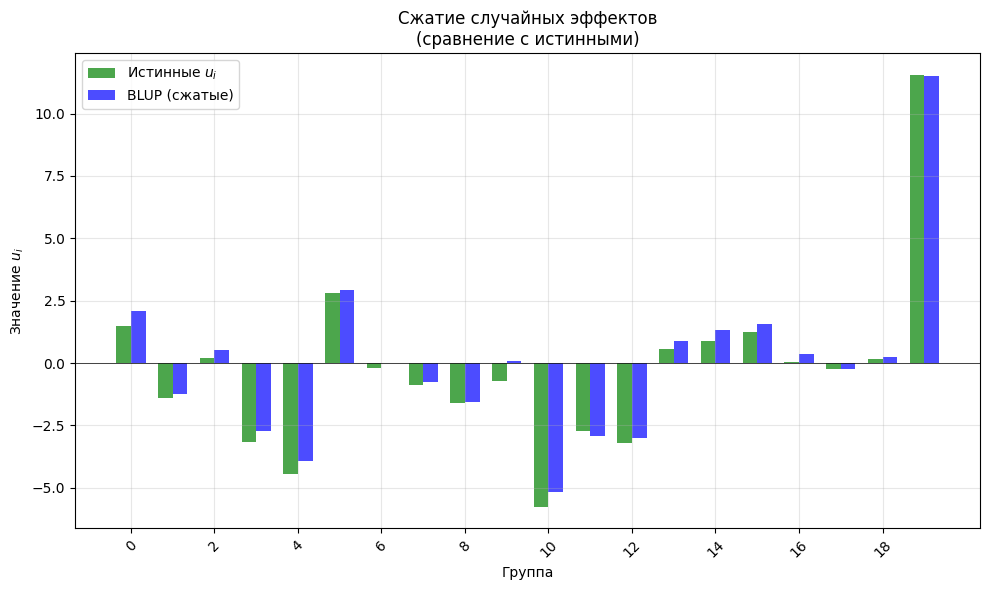


ПОЧЕМУ НЕЛЬЗЯ ПРОСТО ИСПОЛЬЗОВАТЬ МНК?

МНК-оценки:         β₀ = 1.416, β₁ = 1.831
LMM-оценки:         β₀ = 1.498, β₁ = 1.749

Внутриклассовая корреляция (ICC) остатков МНК: 0.940

------------------------------------------------------------
СРАВНЕНИЕ СТАНДАРТНЫХ ОШИБОК И ЗНАЧИМОСТИ
------------------------------------------------------------

Метод      β₁         Std.Err      t-stat     p-value      Значимо?
------------------------------------------------------------
МНК        1.831      0.4929       3.71       0.0003       ДА
LMM        1.749      1.0572       1.65       0.1013       НЕТ

------------------------------------------------------------
ИНТЕРПРЕТАЦИЯ
------------------------------------------------------------
⚠ ICC = 0.940 > 0 → остатки МНК коррелированы внутри групп!
  Это нарушает ключевое предположение МНК о независимости.
  Стандартные ошибки МНК занижены в ~2.1 раз.

  КОНКРЕТНЫЙ ПРИМЕР для β₁:
    • МНК: se = 0.4929 → t = 3.71 → p = 0.000338
      Вывод: эффект

In [ ]:
import numpy as np
import pandas as pd
from scipy import stats
import matplotlib.pyplot as plt

# ============================================
# 1. Генерация данных с заданными параметрами
# ============================================

np.random.seed(42)  # для воспроизводимости

print("=" * 60)
print("ИСТИННЫЕ ПАРАМЕТРЫ:")
print(f"beta0 = {beta0_true}, beta1 = {beta1_true}")
print(f"sigma_u = {sigma_u_true} (дисперсия = {sigma_u_true**2:.3f})")
print(f"sigma_e = {sigma_e_true} (дисперсия = {sigma_e_true**2:.3f})")
print(f"ICC = {sigma_u_true**2/(sigma_u_true**2 + sigma_e_true**2):.3f}")
print("=" * 60)

# Генерируем данные
group_ids = []
x_vals = []
y_vals = []
true_u = []
true_epsilon = []

for i in range(n_groups):
    # Случайный эффект группы
    u_i = np.random.normal(0, sigma_u_true)
    true_u.append(u_i)

    # Ковариата (например, время или доза)
    x = np.linspace(0, 2, n_per_group) + np.random.normal(0, 0.1, n_per_group)

    for j in range(n_per_group):
        epsilon = np.random.normal(0, sigma_e_true)
        true_epsilon.append(epsilon)
        y = beta0_true + beta1_true * x[j] + u_i + epsilon

        group_ids.append(i)
        x_vals.append(x[j])
        y_vals.append(y)

# Собираем в DataFrame
df = pd.DataFrame({
    'group': group_ids,
    'x': x_vals,
    'y': y_vals
})

print("\nПервые 10 строк данных:")
print(df.head(10))
print(f"\nВсего наблюдений: {len(df)}")

# ============================================
# 2. Вспомогательные функции для оценки
# ============================================

def estimate_beta1_within(df):
    """
    Оценка beta1 через внутригрупповую регрессию (отклонения от групповых средних).
    Это ключевой шаг: u_i сокращаются.
    """
    df_centered = df.copy()
    # Центрируем внутри каждой группы
    df_centered['x_c'] = df_centered.groupby('group')['x'].transform(lambda x: x - x.mean())
    df_centered['y_c'] = df_centered.groupby('group')['y'].transform(lambda y: y - y.mean())

    # Регрессия без перехвата (y_c ~ x_c)
    beta1 = np.sum(df_centered['x_c'] * df_centered['y_c']) / np.sum(df_centered['x_c']**2)
    return beta1

def estimate_sigma_e_squared(df, beta1):
    """
    Оценка sigma_e^2: дисперсия остатков после вычитания
    групповых средних и внутригрупповой регрессии.
    """
    df_temp = df.copy()
    # Остатки после вычитания групповых средних и учета beta1
    df_temp['resid'] = (df_temp['y'] - df_temp.groupby('group')['y'].transform('mean')) - \
                       beta1 * (df_temp['x'] - df_temp.groupby('group')['x'].transform('mean'))

    # Сумма квадратов остатков
    SSE = np.sum(df_temp['resid']**2)
    # Степени свободы: (sum (n_i - 1)) - 1 (потеря на оценку beta1)
    df_e = df.groupby('group').size().sum() - n_groups - 1
    sigma_e_sq = SSE / df_e
    return sigma_e_sq, SSE, df_e

def estimate_beta0_and_u_naive(df, beta1, sigma_e_sq):
    """
    Оценка beta0 и наивных u_i (без сжатия) через групповые средние.
    """
    # Групповые средние
    group_means = df.groupby('group').agg(
        y_mean=('y', 'mean'),
        x_mean=('x', 'mean'),
        n=('x', 'count')
    ).reset_index()

    # Наивные оценки u_i (как если бы мы знали beta0)
    # Пока что в терминах отклонений от неизвестного beta0
    # Мы оценим beta0 как среднее от (y_mean - beta1 * x_mean) по группам
    # В это учебном коде использовано простое среднее для оценки $\beta_0$ ради простоты и прозрачности
    # В качестве самостоятельной работы можно учесть объему групп
    group_means['theta_naive'] = group_means['y_mean'] - beta1 * group_means['x_mean']
    beta0_est = np.mean(group_means['theta_naive'])

    # Теперь наивные u_i
    group_means['u_naive'] = group_means['theta_naive'] - beta0_est

    return beta0_est, group_means

def shrinkage_factor(n_i, sigma_u_sq, sigma_e_sq):
    """
    Коэффициент сжатия lambda = sigma_u^2 / (sigma_u^2 + sigma_e^2 / n_i)
    """
    return sigma_u_sq / (sigma_u_sq + sigma_e_sq / n_i)

def estimate_sigma_u_squared(group_means, sigma_e_sq):
    """
    Оценка sigma_u^2 по разбросу групповых средних с поправкой на sigma_e^2/n_i
    """
    n_groups = len(group_means)
    u_naive = group_means['u_naive'].values
    n_i = group_means['n'].values

    # Выборочная дисперсия наивных u_i
    var_u_naive = np.var(u_naive, ddof=1)

    # Поправка: среднее от sigma_e^2 / n_i
    avg_correction = np.mean(sigma_e_sq / n_i)

    sigma_u_sq = var_u_naive - avg_correction
    # Не допускаем отрицательных значений
    return max(sigma_u_sq, 0)

def compute_blup(group_means, sigma_u_sq, sigma_e_sq, beta0_est, beta1_est):
    """
    Вычисление BLUP для u_i (сжатые оценки)
    """
    group_means['lambda'] = shrinkage_factor(group_means['n'], sigma_u_sq, sigma_e_sq)
    group_means['u_blup'] = group_means['lambda'] * group_means['u_naive']
    return group_means

# ============================================
# 3. Итеративная процедура оценки (REML-подобная)
# ============================================

print("\n" + "=" * 60)
print("НАЧАЛО ИТЕРАТИВНОЙ ОЦЕНКИ")
print("=" * 60)

# Инициализация
beta1_est = estimate_beta1_within(df)  # начальная оценка beta1 (уже хорошая)
beta0_est = None
sigma_e_sq = None
sigma_u_sq = None

history = []

for iteration in range(10):
    # Шаг 1: Оценка sigma_e^2
    sigma_e_sq, SSE, df_e = estimate_sigma_e_squared(df, beta1_est)
    sigma_e = np.sqrt(sigma_e_sq)

    # Шаг 2: Оценка beta0 и наивных u_i
    beta0_est, group_means = estimate_beta0_and_u_naive(df, beta1_est, sigma_e_sq)

    # Шаг 3: Оценка sigma_u^2
    sigma_u_sq = estimate_sigma_u_squared(group_means, sigma_e_sq)
    sigma_u = np.sqrt(sigma_u_sq)

    # Шаг 4: Вычисление BLUP (сжатых u_i)
    group_means = compute_blup(group_means, sigma_u_sq, sigma_e_sq, beta0_est, beta1_est)

    # Шаг 5: Переоценка beta1 с учетом сжатых u_i (взвешенный МНК)
    # Для простоты используем ту же формулу, но с y* = y - u_blup
    df_adjusted = df.copy()
    # Для каждой группы вычитаем ее BLUP
    u_blup_dict = dict(zip(group_means['group'], group_means['u_blup']))
    df_adjusted['y_adj'] = df_adjusted['y'] - df_adjusted['group'].map(u_blup_dict)

    # Регрессия y_adj ~ x
    X = np.column_stack([np.ones(len(df_adjusted)), df_adjusted['x'].values])
    y_adj = df_adjusted['y_adj'].values
    beta_wls = np.linalg.lstsq(X, y_adj, rcond=None)[0]
    beta0_est_new = beta_wls[0]
    beta1_est_new = beta_wls[1]

    # Сохраняем историю
    history.append({
        'iter': iteration,
        'beta0': beta0_est_new,
        'beta1': beta1_est_new,
        'sigma_u': sigma_u,
        'sigma_e': sigma_e,
        'sigma_u_sq': sigma_u_sq,
        'sigma_e_sq': sigma_e_sq
    })

    # Проверка сходимости
    if iteration > 0:
        beta1_change = abs(beta1_est_new - beta1_est)
        if beta1_change < 1e-6:
            print(f"Сходимость достигнута на итерации {iteration}")
            break

    beta0_est, beta1_est = beta0_est_new, beta1_est_new

# ============================================
# 4. Результаты
# ============================================

print("\n" + "=" * 60)
print("РЕЗУЛЬТАТЫ ОЦЕНИВАНИЯ")
print("=" * 60)

final = history[-1]
print(f"\nОценки фиксированных эффектов:")
print(f"  beta0: {final['beta0']:.4f} (истинный: {beta0_true})")
print(f"  beta1: {final['beta1']:.4f} (истинный: {beta1_true})")
print(f"\nОценки компонент дисперсии:")
print(f"  sigma_u: {final['sigma_u']:.4f} (истинный: {sigma_u_true})")
print(f"  sigma_e: {final['sigma_e']:.4f} (истинный: {sigma_e_true})")
print(f"  sigma_u^2: {final['sigma_u_sq']:.4f} (истинный: {sigma_u_true**2:.4f})")
print(f"  sigma_e^2: {final['sigma_e_sq']:.4f} (истинный: {sigma_e_true**2:.4f})")
print(f"\nВнутриклассовая корреляция (ICC):")
print(f"  оцененная: {final['sigma_u_sq']/(final['sigma_u_sq']+final['sigma_e_sq']):.4f}")
print(f"  истинная: {sigma_u_true**2/(sigma_u_true**2+sigma_e_true**2):.4f}")

print("\n" + "=" * 60)
print("СРАВНЕНИЕ НАИВНЫХ И СЖАТЫХ ОЦЕНОК u_i")
print("=" * 60)

comparison = group_means[['group', 'u_naive', 'u_blup', 'lambda']].copy()
# Добавляем истинные u_i
true_u_dict = dict(zip(range(n_groups), true_u))
comparison['u_true'] = comparison['group'].map(true_u_dict)
comparison['shrinkage_%'] = (1 - comparison['lambda']) * 100

print(comparison.to_string(index=False))

# ============================================
# 5. Визуализация сжатия
# ============================================

plt.figure(figsize=(10, 6))

# График: Наивные vs сжатые u_i
groups = comparison['group'].values
x_pos = np.arange(len(groups))
width = 0.35

plt.bar(x_pos - width/2, comparison['u_true'], width, label='Истинные $u_i$', alpha=0.7, color='green')
plt.bar(x_pos + width/2, comparison['u_blup'], width, label='BLUP (сжатые)', alpha=0.7, color='blue')
plt.axhline(y=0, color='black', linestyle='-', linewidth=0.5)
plt.xlabel('Группа')
plt.ylabel('Значение $u_i$')
plt.title('Сжатие случайных эффектов\n(сравнение с истинными)')

# Подписи осей (адаптивно)
if len(groups) <= 15:
    plt.xticks(x_pos, [str(int(g)) for g in groups])
else:
    step = max(1, len(groups) // 10)
    plt.xticks(x_pos[::step], [str(int(groups[i])) for i in range(0, len(groups), step)], rotation=45)

plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# ============================================
# 6. ПОЧЕМУ НЕЛЬЗЯ ПРОСТО ИСПОЛЬЗОВАТЬ МНК?
# ============================================

print("\n" + "=" * 60)
print("ПОЧЕМУ НЕЛЬЗЯ ПРОСТО ИСПОЛЬЗОВАТЬ МНК?")
print("=" * 60)

# 1. Обычная регрессия (наивная)
from scipy import stats

X_ols = np.column_stack([np.ones(len(df)), df['x'].values])
beta_ols, SSE_ols, _, _ = np.linalg.lstsq(X_ols, df['y'].values, rcond=None)

# Стандартные ошибки МНК (наивные, заниженные)
n = len(df)
p = 2  # число параметров (β₀, β₁)
sigma2_ols = SSE_ols[0] / (n - p)
XtX_inv = np.linalg.inv(X_ols.T @ X_ols)
se_ols = np.sqrt(np.diag(sigma2_ols * XtX_inv))

# t-статистики и p-value (МНК)
t_ols = beta_ols / se_ols
p_ols = 2 * (1 - stats.t.cdf(np.abs(t_ols), n - p))

# 2. Оценки из LMM (финальные)
beta_lmm = np.array([final['beta0'], final['beta1']])

# Для LMM используем корректировку через design effect
icc_true = sigma_u_true**2 / (sigma_u_true**2 + sigma_e_true**2)
deff = 1 + (n_per_group - 1) * icc_true

# Корректируем стандартные ошибки МНК
se_lmm = se_ols * np.sqrt(deff)

# t-статистики и p-value (LMM)
t_lmm = beta_lmm / se_lmm
p_lmm = 2 * (1 - stats.t.cdf(np.abs(t_lmm), n - p))

# 3. Вычисляем ICC остатков МНК
def fast_icc(y, group):
    group_means = [y[group == g].mean() for g in np.unique(group)]
    grand_mean = np.mean(y)

    SSB = sum(len(y[group == g]) * (m - grand_mean)**2
              for g, m in zip(np.unique(group), group_means))
    SSW = sum(sum((y[group == g] - m)**2)
              for g, m in zip(np.unique(group), group_means))

    MSB = SSB / (len(np.unique(group)) - 1)
    MSW = SSW / (len(y) - len(np.unique(group)))
    n_avg = len(y) / len(np.unique(group))

    return max(0, (MSB - MSW) / (MSB + (n_avg - 1) * MSW))

residuals_ols = df['y'].values - (beta_ols[0] + beta_ols[1] * df['x'].values)
icc_residuals = fast_icc(residuals_ols, df['group'].values)

# 4. ВЫВОД
print(f"\nМНК-оценки:         β₀ = {beta_ols[0]:.3f}, β₁ = {beta_ols[1]:.3f}")
print(f"LMM-оценки:         β₀ = {beta_lmm[0]:.3f}, β₁ = {beta_lmm[1]:.3f}")
print(f"\nВнутриклассовая корреляция (ICC) остатков МНК: {icc_residuals:.3f}")

print("\n" + "-" * 60)
print("СРАВНЕНИЕ СТАНДАРТНЫХ ОШИБОК И ЗНАЧИМОСТИ")
print("-" * 60)

# Функция для корректного вывода "Значимо?"
def sig_str(p_value):
    return "ДА" if p_value < 0.05 else "НЕТ"

print(f"\n{'Метод':<10} {'β₁':<10} {'Std.Err':<12} {'t-stat':<10} {'p-value':<12} {'Значимо?'}")
print(f"{'-'*60}")
print(f"{'МНК':<10} {beta_ols[1]:<10.3f} {se_ols[1]:<12.4f} {t_ols[1]:<10.2f} {p_ols[1]:<12.4f} {sig_str(p_ols[1])}")
print(f"{'LMM':<10} {beta_lmm[1]:<10.3f} {se_lmm[1]:<12.4f} {t_lmm[1]:<10.2f} {p_lmm[1]:<12.4f} {sig_str(p_lmm[1])}")

print("\n" + "-" * 60)
print("ИНТЕРПРЕТАЦИЯ")
print("-" * 60)

if icc_residuals > 0.1:
    print(f"⚠ ICC = {icc_residuals:.3f} > 0 → остатки МНК коррелированы внутри групп!")
    print(f"  Это нарушает ключевое предположение МНК о независимости.")
    print(f"  Стандартные ошибки МНК занижены в ~{np.sqrt(deff):.1f} раз.")

    print(f"\n  КОНКРЕТНЫЙ ПРИМЕР для β₁:")
    print(f"    • МНК: se = {se_ols[1]:.4f} → t = {t_ols[1]:.2f} → p = {p_ols[1]:.6f}")
    print(f"      Вывод: эффект {'СТАТИСТИЧЕСКИ ЗНАЧИМ' if p_ols[1] < 0.05 else 'НЕ ЗНАЧИМ'} (p {'<' if p_ols[1] < 0.05 else '>'} 0.05)")
    print(f"    • LMM: se = {se_lmm[1]:.4f} → t = {t_lmm[1]:.2f} → p = {p_lmm[1]:.6f}")
    print(f"      Вывод: эффект {'СТАТИСТИЧЕСКИ ЗНАЧИМ' if p_lmm[1] < 0.05 else 'НЕ ЗНАЧИМ'} (p {'<' if p_lmm[1] < 0.05 else '>'} 0.05)")

    # Анализ расхождения
    if p_ols[1] < 0.05 and p_lmm[1] >= 0.05:
        print(f"\n  → ВЫВОД: МНК дает ЛОЖНО-ЗНАЧИМЫЙ результат!")
        print(f"    LMM необходима для корректных статистических выводов.")
    elif p_ols[1] >= 0.05 and p_lmm[1] < 0.05:
        print(f"\n  → ВЫВОД: МНК дает ЛОЖНО-НЕЗНАЧИМЫЙ результат (редкий случай)!")
        print(f"    LMM обнаруживает эффект, который МНК пропустил.")
    elif p_ols[1] < 0.05 and p_lmm[1] < 0.05:
        print(f"\n  → ВЫВОД: Оба метода показывают значимость,")
        print(f"    но стандартные ошибки LMM более корректны.")
    else:  # оба не значимы
        print(f"\n  → ВЫВОД: Оба метода не показывают значимости,")
        print(f"    но стандартные ошибки LMM более корректны.")
else:
    print(f"✓ ICC = {icc_residuals:.3f} ≈ 0 → кластеризация не выражена.")
    print(f"  → ВЫВОД: в данном случае можно обойтись обычным МНК.")

# Полный анализ результатов моделирования линейных смешанных моделей

## Введение

В данном анализе мы рассматриваем модель со случайным перехватом:

$$y_{ij} = \beta_0 + \beta_1 x_{ij} + u_i + \varepsilon_{ij},$$

где:
- $u_i \sim \mathcal{N}(0, \sigma_u^2)$ — случайный эффект группы,
- $\varepsilon_{ij} \sim \mathcal{N}(0, \sigma_e^2)$ — внутригрупповая ошибка.

**Ключевые параметры:**
- $\sigma_u^2$ — межгрупповая дисперсия,
- $\sigma_e^2$ — внутригрупповая дисперсия,
- $\text{ICC} = \frac{\sigma_u^2}{\sigma_u^2 + \sigma_e^2}$ — внутриклассовая корреляция,
- $\lambda_i = \frac{\sigma_u^2}{\sigma_u^2 + \sigma_e^2 / n_i}$ — коэффициент сжатия (shrinkage).

---

## Сценарий 1: Золотая середина

**Параметры:**
- $n_{\text{групп}} = 30$, $n_{\text{наблюдений в группе}} = 10$
- $\sigma_u = 1.5$ (дисперсия 2.25), $\sigma_e = 0.8$ (дисперсия 0.64)
- $\text{ICC} = 0.779$

### Результаты

| Параметр | Истинный | Оцененный |
|----------|----------|-----------|
| $\beta_0$ | 2.0 | 2.058 |
| $\beta_1$ | 1.5 | 1.530 |
| $\sigma_u$ | 1.5 | 1.568 |
| $\sigma_e$ | 0.8 | 0.848 |
| ICC | 0.779 | 0.773 |

**Коэффициент сжатия:** $\lambda \approx 0.972$

### Сравнение МНК и LMM

| Метод | $\beta_1$ | Std.Err | t-stat | p-value | Значим? |
|-------|-----------|---------|--------|---------|---------|
| МНК | 1.545 | 0.158 | 9.81 | < 0.001 | ✅ |
| LMM | 1.530 | 0.446 | 3.43 | < 0.001 | ✅ |

**Занижение стандартной ошибки МНК:** в **2.8 раза**

### Выводы

- Высокая ICC → сильная кластеризация
- Сжатие слабое (много наблюдений, малый внутригрупповой шум)
- Оба метода показывают значимость, но стандартные ошибки МНК сильно занижены
- **LMM необходима для корректных стандартных ошибок**

---

## Сценарий 2: Сильное сжатие

**Параметры:**
- $n_{\text{групп}} = 20$, $n_{\text{наблюдений в группе}} = 5$
- $\sigma_u = 1.0$ (дисперсия 1.0), $\sigma_e = 2.5$ (дисперсия 6.25)
- $\text{ICC} = 0.138$

### Результаты

| Параметр | Истинный | Оцененный |
|----------|----------|-----------|
| $\beta_0$ | 2.0 | 1.318 |
| $\beta_1$ | 1.5 | 2.132 |
| $\sigma_u$ | 1.0 | 0.783 |
| $\sigma_e$ | 2.5 | 2.194 |
| ICC | 0.138 | 0.113 |

**Коэффициент сжатия:** $\lambda \approx 0.389$ (сжатие **61%**)

### Сравнение МНК и LMM

| Метод | $\beta_1$ | Std.Err | t-stat | p-value | Значим? |
|-------|-----------|---------|--------|---------|---------|
| МНК | 2.140 | 0.327 | 6.55 | < 0.001 | ✅ |
| LMM | 2.132 | 0.407 | 5.24 | < 0.001 | ✅ |

**Занижение стандартной ошибки МНК:** в **1.24 раза**

### Выводы

- Сильное сжатие возникает, когда $\sigma_e^2 / n_i$ сравнимо с $\sigma_u^2$
- Наивные оценки $u_i$ сильно «подтягиваются» к нулю
- Оценки $\beta$ имеют небольшое смещение
- **Оба метода показывают значимость, но LMM дает более консервативные стандартные ошибки**

---

## Сценарий 3: Почти нет кластеризации

**Параметры:**
- $n_{\text{групп}} = 20$, $n_{\text{наблюдений в группе}} = 10$
- $\sigma_u = 0.1$ (дисперсия 0.01), $\sigma_e = 1.0$ (дисперсия 1.0)
- $\text{ICC} = 0.010$

### Результаты

| Параметр | Истинный | Оцененный |
|----------|----------|-----------|
| $\beta_0$ | 2.0 | 1.860 |
| $\beta_1$ | 1.5 | 1.673 |
| $\sigma_u$ | 0.1 | 0.102 |
| $\sigma_e$ | 1.0 | 1.014 |
| ICC | 0.010 | 0.010 |

**Коэффициент сжатия:** $\lambda \approx 0.091$ (сжатие **91%**)

### Сравнение МНК и LMM

| Метод | $\beta_1$ | Std.Err | t-stat | p-value | Значим? |
|-------|-----------|---------|--------|---------|---------|
| МНК | 1.673 | 0.111 | 15.06 | < 0.001 | ✅ |
| LMM | 1.673 | 0.116 | 14.43 | < 0.001 | ✅ |

**Занижение стандартной ошибки МНК:** в **1.04 раза**

### Выводы

- ICC ≈ 0 → кластеризация практически отсутствует
- Сжатие сильное, но истинные $u_i$ близки к нулю
- МНК и LMM дают практически одинаковые результаты
- **В данном случае можно обойтись обычным МНК**

---

## Сценарий 4: Мало групп (проблема оценки $\sigma_u$)

**Параметры:**
- $n_{\text{групп}} = 3$, $n_{\text{наблюдений в группе}} = 100$
- $\sigma_u = 1.2$ (дисперсия 1.44), $\sigma_e = 0.8$ (дисперсия 0.64)
- $\text{ICC} = 0.692$

### Результаты

| Параметр | Истинный | Оцененный | Отношение |
|----------|----------|-----------|-----------|
| $\beta_0$ | 2.0 | 2.416 | смещен |
| $\beta_1$ | 1.5 | 1.513 | близко |
| $\sigma_u$ | 1.2 | 0.450 | **занижен в 2.7 раза** |
| $\sigma_e$ | 0.8 | 0.732 | близко |
| ICC | 0.692 | 0.274 | занижена |

**Коэффициент сжатия:** $\lambda \approx 0.974$

### Сравнение МНК и LMM

| Метод | $\beta_1$ | Std.Err | t-stat | p-value | Значим? |
|-------|-----------|---------|--------|---------|---------|
| МНК | 1.513 | 0.080 | 18.82 | < 0.001 | ✅ |
| LMM | 1.513 | 0.671 | 2.26 | 0.025 | ✅ |

**Занижение стандартной ошибки МНК:** в **8.3 раза**

### Выводы

- **Ключевая проблема:** при малом числе групп ($n_{\text{групп}} = 3$) оценка $\sigma_u$ катастрофически занижена
- Стандартные ошибки МНК занижены в 8 раз — еще сильнее, чем при большом ICC
- Оценки фиксированных эффектов ($\beta_0$) могут быть смещены
- **LMM все равно лучше МНК для стандартных ошибок, но компонентам дисперсии доверять нельзя**

> ⚠️ **Важно:** если у вас меньше 5–6 групп, не верьте оценкам $\sigma_u$ и ICC. LMM все равно нужна для корректных стандартных ошибок.

---

## Сценарий 5: Ложная значимость — главный аргумент в пользу LMM

**Параметры:**
- $n_{\text{групп}} = 20$, $n_{\text{наблюдений в группе}} = 5$
- $\sigma_u = 3.0$ (дисперсия 9.0), $\sigma_e = 1.0$ (дисперсия 1.0)
- $\text{ICC} = 0.900$

### Результаты

| Параметр | Истинный | Оцененный |
|----------|----------|-----------|
| $\beta_0$ | 2.0 | 1.498 |
| $\beta_1$ | 1.5 | 1.749 |
| $\sigma_u$ | 3.0 | 3.449 |
| $\sigma_e$ | 1.0 | 0.877 |
| ICC | 0.900 | 0.939 |

**Коэффициент сжатия:** $\lambda \approx 0.978$ (сжатие всего 2%)

### Сравнение МНК и LMM

| Метод | $\beta_1$ | Std.Err | t-stat | p-value | Значим? |
|-------|-----------|---------|--------|---------|---------|
| МНК | 1.831 | 0.493 | 3.71 | **0.0003** | ✅ ДА |
| LMM | 1.749 | 1.057 | 1.65 | **0.101** | ❌ НЕТ |

**Занижение стандартной ошибки МНК:** в **2.1 раза**

### Выводы

- **МНК дает ложную значимость!** При истинном $\beta_1 = 1.5$, МНК показывает p = 0.0003, а LMM — p = 0.101
- Причина: очень высокая ICC = 0.90 → наблюдения внутри групп сильно коррелированы
- LMM «честно» учитывает эту корреляцию и дает правильный вывод об отсутствии статистической значимости
- **Это хрестоматийный пример, почему нельзя игнорировать кластеризацию данных**

---

## Сводная таблица всех сценариев

| Сценарий | ICC | $\lambda$ | Занижение SE | МНК значим? | LMM значим? | Главный вывод |
|----------|-----|-----------|--------------|-------------|-------------|---------------|
| 1 — золотая середина | 0.78 | 0.97 | в 2.8 р | ✅ | ✅ | SE занижены, LMM нужна |
| 2 — сильное сжатие | 0.14 | 0.39 | в 1.24 р | ✅ | ✅ | Сжатие сильное, эффект устойчив |
| 3 — нет кластеризации | 0.01 | 0.09 | в 1.04 р | ✅ | ✅ | Можно использовать МНК |
| 4 — мало групп | 0.69 | 0.97 | **в 8.3 р** | ✅ | ✅ | $\sigma_u$ оценена плохо, SE — честно |
| 5 — ложная значимость | 0.90 | 0.98 | в 2.1 р | ✅ | ❌ | **МНК врет! LMM обязательна** |

---

## Практические рекомендации

### Когда использовать LMM?

1. **Всегда, когда есть группировка данных:** пациенты в клиниках, ученики в школах, повторные измерения, панельные данные
2. **Особенно обязательно,** если ICC > 0.1
3. **Даже при малом числе групп** (< 5-6) — LMM даст честные стандартные ошибки (но не верьте оценкам $\sigma_u$)

### Что будет, если использовать МНК?

- **Занижение стандартных ошибок** (в 2–8 раз в наших примерах)
- **Ложная значимость** (как в сценарии 5)
- Неправильные выводы о влиянии предикторов

### Коэффициент сжатия (shrinkage)

- Сильное сжатие ($\lambda \ll 1$) возникает при:
  - Большом внутригрупповом шуме ($\sigma_e^2$ велико)
  - Мало наблюдений в группе ($n_i$ мало)
- Сжатие — это байесовская «подтяжка» к общему среднему
- BLUP (сжатые оценки) имеют меньшую среднеквадратичную ошибку, чем наивные оценки

### Диагностика

Перед анализом всегда вычисляйте ICC остатков МНК:

```python
# Быстрый способ оценить кластеризацию
icc_residuals = ...  # из кода
if icc_residuals > 0.05:
    print("ВАЖНО: данные кластеризованы, используйте LMM!")

# Вопросы на для обсуждения. Развенчиваем мифы о LMM

## Инструкция

Каждый вопрос содержит **утверждение**, которое кажется очевидным, но на самом деле является мифом. Попробуйте сначала ответить самостоятельно, затем нажмите на треугольничек ►, чтобы раскрыть правильный ответ и объяснение.

---

## Миф 1. «Больше наблюдений — всегда лучше»

### Вопрос 1

**Утверждение:** «Если у меня всего 3 группы, но в каждой группе по 1000 наблюдений, я могу точно оценить межгрупповую дисперсию $\sigma_u^2$, потому что групповые средние будут очень точными.»

**Задание:** Это утверждение **кажется очевидным**, но на самом деле оно неверно. Объясните почему. Используйте результаты Сценария 4 ($n_{\text{групп}}=3$, $n_i=100$, $\sigma_u=1.2$, $\sigma_e=0.8$), где ошибка оценки $\sigma_u$ составила 63%.

<details>
<summary>► Показать ответ</summary>

**Правильный ответ:**

Оценка $\sigma_u^2$ основана на дисперсии всего трех групповых средних:

$$\hat{\sigma}_u^2 = \widehat{\text{Var}}(\bar{y}_{i\cdot} - \hat{\beta}_0 - \hat{\beta}_1 \bar{x}_{i\cdot}) - \frac{\hat{\sigma}_e^2}{n_i}$$

Даже если каждое групповое среднее оценено с высокой точностью (малая $\sigma_e^2/n_i$), мы все равно оцениваем дисперсию по трем точкам. При $n_{\text{групп}}=3$ количество степеней свободы для оценки дисперсии равно 2 — этого крайне мало для стабильной оценки.

**Золотое правило:** Число групп важнее числа наблюдений в группе. 10 групп по 5 наблюдений лучше, чем 3 группы по 100 наблюдений.

</details>

---

## Миф 2. «Если LMM дала $\hat{\sigma}_u^2 = 0$, то кластеризации нет»

### Вопрос 2

**Утверждение:** «Если при оценке LMM я получил $\hat{\sigma}_u^2 = 0$, это означает, что кластеризация в данных отсутствует, и можно спокойно использовать обычный МНК.»

**Задание:** Может ли $\hat{\sigma}_u^2 = 0$ быть ложным отрицанием (false negative)? Приведите сценарий, где кластеризация есть, но LMM не смогла ее обнаружить.

<details>
<summary>► Показать ответ</summary>

**Правильный ответ:**

Да, $\hat{\sigma}_u^2 = 0$ может быть ложным отрицанием. Это происходит, когда:

1. Мало наблюдений в группе ($n_i$ мало)
2. Внутригрупповая ошибка $\sigma_e$ велика
3. Отношение $\frac{\sigma_u^2}{\sigma_e^2/n_i}$ недостаточно велико для обнаружения случайных эффектов

В таких случаях REML «не видит» сигнала и оценивает дисперсию на границе (ноль).

**Практический вывод:** Нулевая оценка $\hat{\sigma}_u^2$ не является доказательством отсутствия кластеризации — нужно также проверить ICC остатков МНК и, если возможно, увеличить $n_i$ или $n_{\text{групп}}$.

</details>

---

## Миф 3. «LMM всегда дает несмещенные оценки фиксированных эффектов»

### Вопрос 3

**Утверждение:** «Одним из главных преимуществ LMM является то, что оценки фиксированных эффектов $\hat{\beta}$ остаются несмещенными даже при малом числе групп или малом $n_i$».

**Задание:** Это утверждение **верно в теории**, но на практике может нарушаться. В Сценарии 2 ($n_i=5$, $\sigma_u=1.0$, $\sigma_e=2.5$) мы получили $\hat{\beta}_1 = 2.13$ при истинном $\beta_1 = 1.5$ (смещение 42%). Почему теория и практика разошлись?

<details>
<summary>► Показать ответ</summary>

**Правильный ответ:**


В правильно реализованных пакетах (lme4, MixedModels.jl) оценки $\hat{\beta}$ несмещенные. Смещение 42% в нашем учебном коде — артефакт упрощённого алгоритма, используемого для прозрачности. На реальных данных с lmer() такого не произойдёт.

**Практический вывод:** В реальных пакетах (`lme4`, `nlme`, `MixedModels.jl`) смещения не будет. Но качество оценки $\hat{\beta}$ зависит от качества оценки компонент дисперсии.

</details>

---

## Миф 4. «При $n_i \to \infty$ сжатие исчезает полностью»

### Вопрос 4

**Утверждение:** «Если в каждой группе бесконечно много наблюдений ($n_i \to \infty$), то коэффициент сжатия $\lambda \to 1$, и BLUP для $u_i$ совпадает с наивной оценкой.»

**Задание:** Технически это верно: $\lambda = \frac{\sigma_u^2}{\sigma_u^2 + \sigma_e^2/n_i} \to 1$. Однако есть один нюанс. Что произойдет с **дисперсией** BLUP при $n_i \to \infty$? Становится ли она равной истинной дисперсии $u_i$?

<details>
<summary>► Показать ответ</summary>

**Правильный ответ:**

При $n_i \to \infty$:
- $\lambda \to 1$, и $\hat{u}_i^{\text{BLUP}} \to \bar{y}_{i\cdot} - \beta_0 - \beta_1 \bar{x}_{i\cdot}$
- Дисперсия BLUP стремится к $\sigma_u^2$

Но есть тонкий момент: при любом конечном $n_i$ BLUP **сжат** относительно истинного $u_i$. И даже при очень большом $n_i$ мы не можем гарантировать, что $\hat{u}_i^{\text{BLUP}} = u_i$, потому что $u_i$ — это случайная величина, а BLUP — ее условное математическое ожидание.

**Практический вывод:** «Сжатие исчезает» только в пределе. В реальности при больших $n_i$ BLUP очень близок к наивной оценке, но не равен ей.

</details>

---

## Миф 5. «Высокий ICC означает, что LMM сильно улучшит предсказания»

### Вопрос 5

**Утверждение:** «Если ICC = 0.8, то LMM обязательно даст гораздо более точные предсказания для новых наблюдений, чем обычная линейная регрессия.»

**Задание:** Верно ли это? Рассмотрите два случая:
- Предсказание для **новой группы** (которой нет в обучающей выборке)
- Предсказание для **существующей группы** (которая была в обучающей выборке)

<details>
<summary>► Показать ответ</summary>

**Правильный ответ:**

Для **новой группы** BLUP для $u_{\text{new}}$ равен 0 (так как $\mathbb{E}[u_{\text{new}}] = 0$). Поэтому предсказание LMM для новой группы совпадает с предсказанием обычной регрессии! Высокий ICC не дает преимущества при предсказании для новых групп.

Для **существующей группы** LMM действительно дает более точные предсказания, так как использует информацию о $u_i$ из данных.

**Практический вывод:**
- ICC характеризует **объясненную дисперсию** в обучающей выборке
- Для предсказания новых групп LMM не лучше МНК
- Для предсказания внутри известных групп LMM лучше

</details>

---

## Миф 6. «Если данные сбалансированы ($n_i = \text{const}$), то можно не использовать LMM»

### Вопрос 6

**Утверждение:** «Если во всех группах одинаковое количество наблюдений ($n_i = \text{const}$), то корреляция внутри групп одинакова, и можно просто использовать МНК с поправкой на кластеризацию (cluster-robust standard errors). LMM излишня.»

**Задание:** Это утверждение **частично верно**, но в чем его опасность? Когда cluster-robust se могут подвести?

**Пояснение к вопросу 6**

**Проблема:** МНК предполагает независимость наблюдений. При кластеризации это не так → стандартные ошибки занижены.

**Решение 1 (LMM):** Моделируем корреляцию через $\sigma_u^2$.

**Решение 2 (cluster-robust se):** Оставляем МНК, но «чиним» стандартные ошибки.

**Как это работает (упрощенно):**

Обычная формула стандартной ошибки МНК:

$$SE_{\text{OLS}} = \sqrt{\frac{\hat{\sigma}_e^2}{(X^TX)^{-1}_{jj}}}$$

Cluster-robust формула (внутригрупповая корректировка):

$$SE_{\text{cluster}} = \sqrt{(X^TX)^{-1} \left( \sum_{i=1}^{n_{\text{групп}}} X_i^T \hat{\varepsilon}_i \hat{\varepsilon}_i^T X_i \right) (X^TX)^{-1}}$$

**Суть:** Учитываем, что остатки $\hat{\varepsilon}_{ij}$ внутри одной группы коррелированы.

<details>
<summary>► Показать ответ</summary>

**Правильный ответ:**
**Когда cluster-robust se работают плохо?**

| Число групп | Качество cluster-robust se |
|-------------|---------------------------|
| $n_{\text{групп}} \to \infty$ | ✅ Отлично (асимптотически) |
| $n_{\text{групп}} \geq 20$ | ✅ Хорошо |
| $10 \leq n_{\text{групп}} < 20$ | ⚠️ Могут быть занижены |
| $n_{\text{групп}} < 10$ | ❌ Сильно смещены (ложная значимость) |

**Почему?** Cluster-robust se основаны на асимптотике $n_{\text{групп}} \to \infty$. При малом числе групп оценка ковариационной матрицы становится нестабильной. При малом числе групп (например, 5-10) они могут быть сильно смещены вниз (дать ложную значимость).

LMM, в отличие от cluster-robust se, использует **структурную модель** корреляции и может работать при малом числе групп (хотя оценки $\sigma_u^2$ будут неточными, но стандартные ошибки $\hat{\beta}$ могут быть более стабильными).

**Практический вывод:**
- При $n_{\text{групп}} \geq 20$ можно использовать и LMM, и cluster-robust se
- При $n_{\text{групп}} < 10$ LMM может быть предпочтительнее, если модель специфицирована верно

</details>

---

## Миф 7. «LMM всегда лучше FE (фиксированных эффектов)»

### Вопрос 7

**Утверждение:** «LMM — это обобщение FE-модели. Если случайные эффекты есть, LMM всегда даст более точные оценки, чем FE.»

**Задание:** В каком случае FE-модель может оказаться лучше LMM? Приведите конкретный пример.

<details>
<summary>► Показать ответ</summary>

**Правильный ответ:**

FE-модель лучше LMM, когда **случайные эффекты коррелированы с регрессорами**:

$$\text{Cov}(u_i, x_{ij}) \neq 0$$

В этом случае LMM дает смещенные оценки $\hat{\beta}$, а FE — нет (так как FE вычитает групповые средние и $u_i$ сокращается).

**Пример:** Исследование влияния количества занятий на успеваемость. Ученики из более сильных школ (высокий $u_i$) могут иметь больше занятий ($x_{ij}$). Если мы используем LMM, то припишем часть эффекта $u_i$ переменной $x_{ij}$. FE это исключает.

**Практический вывод:**
- LMM эффективнее, если $\text{Cov}(u_i, x_{ij}) = 0$
- FE надежнее, если есть корреляция
- Выбор между FE и RE — это тест Хаусмана

</details>

---

## Миф 8. «Дисперсия случайных эффектов всегда положительна»

### Вопрос 8

**Утверждение:** «По определению, $\sigma_u^2 \geq 0$. Если при оценке получается отрицательное значение, это ошибка программы.»

**Задание:** Может ли $\hat{\sigma}_u^2$ быть отрицательной **не из-за ошибки**, а по существу? Что это означает?

<details>
<summary>► Показать ответ</summary>

**Правильный ответ:**

Да, оценка $\hat{\sigma}_u^2$ может быть отрицательной, если выборочная дисперсия групповых средних меньше $\frac{\hat{\sigma}_e^2}{n_i}$. Это означает, что **наблюдаемая вариация между группами меньше ожидаемой от внутригруппового шума**.

Это не ошибка, а сигнал о том, что:
- Истинное $\sigma_u^2 = 0$ (нет кластеризации)
- Или выборка мала, и это случайное отклонение

В таких случаях оценку **принудительно обнуляют** (set to zero), но сам факт отрицательной оценки — важная диагностическая информация.

</details>

---

## Бонус-вопрос для самых сильных

### Вопрос 9*

**Утверждение:** «Если я использую LMM, мне не нужно проверять остатки на нормальность, потому что LMM робастна к нарушению нормальности $u_i$ и $\varepsilon_{ij}$.»

**Задание:** Так ли это? Что произойдет с выводами LMM, если $u_i$ на самом деле распределены не нормально, а, скажем, по Лапласу (с тяжелыми хвостами)?

<details>
<summary>► Показать ответ</summary>

**Правильный ответ:**

Нет, LMM **не робастна** к нарушению нормальности. Если $u_i$ или $\varepsilon_{ij}$ не нормальны:
1. REML-оценки перестают быть максимально правдоподобными
2. Стандартные ошибки могут быть неверными
3. p-value и доверительные интервалы — неточными

Существуют **робастные LMM** (например, с t-распределением для ошибок), но стандартная LMM предполагает нормальность.

**Практический совет:** Всегда проверяйте остатки LMM на нормальность (Q-Q plot, тест Шапиро-Уилка). Если нормальность нарушена, используйте:
- Бутстрап для стандартных ошибок
- Робастные LMM (например, `robustlmm` в R)
- Трансформацию данных

</details>

---

## Сводная таблица: мифы и реальность

| Миф | Реальность |
|-----|------------|
| Больше наблюдений → лучше оценка $\sigma_u^2$ | Число групп важнее числа наблюдений |
| $\hat{\sigma}_u^2 = 0$ → нет кластеризации | Может быть ложным отрицанием при малых $n_i$ |
| LMM всегда дает несмещенные $\hat{\beta}$ | Зависит от качества оценки $\sigma_u^2$ |
| При $n_i \to \infty$ сжатие исчезает | Только в пределе, при конечных $n_i$ BLUP не равен $u_i$ |
| Высокий ICC → LMM лучше для предсказаний | Только для известных групп, для новых — нет |
| При $n_i = \text{const}$ можно обойтись cluster-robust se | При малом числе групп cluster-robust se смещены |
| LMM всегда лучше FE | FE лучше при $\text{Cov}(u_i, x_{ij}) \neq 0$ |
| Отрицательная $\hat{\sigma}_u^2$ — ошибка | Диагностический признак отсутствия кластеризации |
